In [1]:
# ============================================================
# 污水处理厂出水水质预测项目
# Notebook 02: Exploratory Data Analysis (EDA)
#
# 目的：
# 1. 分析 COD、TN、TP 出水水质的分布和时间变化
# 2. 分析相邻时间点之间的水质变化幅度
# 3. 分析 22 个 process features 与三个 target 的关系
# 4. 分析 process features 之间的相关性
# 5. 初步判断除了历史 eff 之外，
#    process variables 是否可能提供额外的预测信息
#
# 注意：
# 本 Notebook 只进行探索性数据分析。
# 暂时不进行 train/test split、scaling 或模型训练。
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Libraries imported successfully.")

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Libraries imported successfully.


In [2]:
# ============================================================
# 1. 读取 COD、TN、TP 数据
#
# 三个数据集共享相同的 22 个 process features，
# 但 eff 分别代表：
#
# COD dataset -> Effluent COD
# TN dataset  -> Effluent TN
# TP dataset  -> Effluent TP
# ============================================================

DATA_DIR = Path("../data")

cod = pd.read_csv(DATA_DIR / "cod.csv")
tn = pd.read_csv(DATA_DIR / "tn.csv")
tp = pd.read_csv(DATA_DIR / "tp.csv")

datasets = {
    "COD": cod,
    "TN": tn,
    "TP": tp
}

# 将时间变量转换为 datetime
for df in datasets.values():
    df["sampling_time"] = pd.to_datetime(df["sampling_time"])

# 22 个 process features
process_features = [
    col for col in cod.columns
    if col not in ["sampling_time", "eff"]
]

print("Data loaded successfully.")
print(f"Number of process features: {len(process_features)}")

Data loaded successfully.
Number of process features: 22


In [3]:
# ============================================================
# 2. Target 基本统计
#
# 查看 COD、TN、TP 的：
# - Mean
# - Median
# - Standard Deviation
# - Minimum
# - Maximum
# ============================================================

target_stats = []

for name, df in datasets.items():

    target_stats.append({
        "Target": name,
        "Mean": df["eff"].mean(),
        "Median": df["eff"].median(),
        "Std": df["eff"].std(),
        "Min": df["eff"].min(),
        "Max": df["eff"].max()
    })

target_stats = pd.DataFrame(target_stats)

target_stats

,Target,Mean,Median,Std,Min,Max
0,COD,9.738127,9.687473,1.983320,5.192459,15.950963
1,TN,8.563547,8.630224,2.150683,3.430930,14.457026
2,TP,0.530925,0.435349,0.325363,0.071559,2.473674


In [4]:
# ============================================================
# 3. 两小时 Target Change
#
# 数据每 2 小时记录一次。
#
# change:
# 当前时间点 eff - 前一个时间点 eff
#
# abs_change:
# 不考虑方向，只看变化幅度。
#
# 目的：
# 判断 COD、TN、TP 在正常情况下每两个小时变化多少。
# ============================================================

change_summary = []

for name, df in datasets.items():

    change = df["eff"].diff()
    abs_change = change.abs()

    change_summary.append({
        "Target": name,
        "Mean Absolute Change": abs_change.mean(),
        "Median Absolute Change": abs_change.median(),
        "90th Percentile": abs_change.quantile(0.90),
        "95th Percentile": abs_change.quantile(0.95),
        "99th Percentile": abs_change.quantile(0.99),
        "Max Absolute Change": abs_change.max()
    })

change_summary = pd.DataFrame(change_summary)

change_summary

,Target,Mean Absolute Change,Median Absolute Change,90th Percentile,95th Percentile,99th Percentile,Max Absolute Change
0,COD,0.102181,0.078195,0.220684,0.274489,0.407690,0.655655
1,TN,0.126275,0.096420,0.270883,0.346103,0.539803,0.941278
2,TP,0.016921,0.009711,0.038155,0.056245,0.117493,0.463248


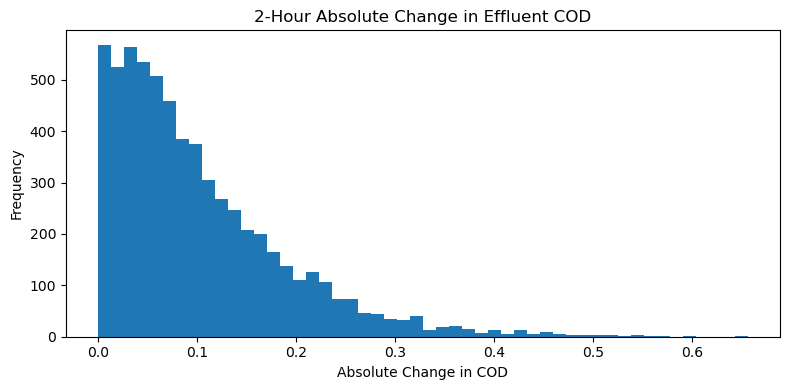

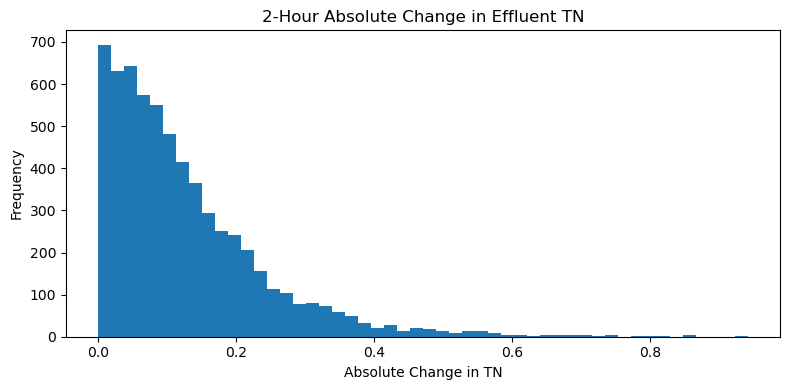

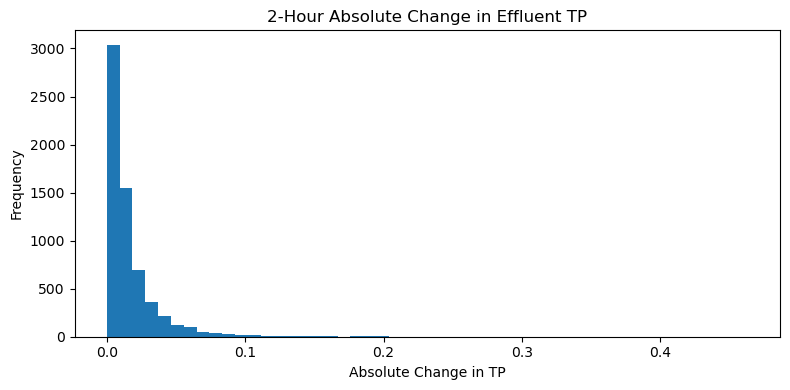

In [5]:
# ============================================================
# 4. Target Change Distribution
#
# 观察每两个小时 COD、TN、TP 的变化幅度。
#
# 如果绝大多数变化集中在 0 附近，
# 说明 target 具有很强的短期稳定性。
# ============================================================

for name, df in datasets.items():

    abs_change = df["eff"].diff().abs().dropna()

    plt.figure(figsize=(8, 4))

    plt.hist(abs_change, bins=50)

    plt.title(f"2-Hour Absolute Change in Effluent {name}")
    plt.xlabel(f"Absolute Change in {name}")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [6]:
# ============================================================
# 5. High-Change Periods
#
# 定义：
# 如果某个时间点的 absolute change
# 大于该 target 的 95th percentile，
# 就将其定义为 High-Change Period。
#
# 这个定义不是行业标准，
# 只是为了后续进行模型 error analysis。
# ============================================================

high_change_summary = []

for name, df in datasets.items():

    abs_change = df["eff"].diff().abs()

    threshold = abs_change.quantile(0.95)

    high_change = abs_change > threshold

    high_change_summary.append({
        "Target": name,
        "95% Change Threshold": threshold,
        "High-Change Observations": high_change.sum(),
        "Percentage": high_change.mean() * 100
    })

high_change_summary = pd.DataFrame(high_change_summary)

high_change_summary

,Target,95% Change Threshold,High-Change Observations,Percentage
0,COD,0.274489,315,5.008745
1,TN,0.346103,315,5.008745
2,TP,0.056245,315,5.008745


In [7]:
# ============================================================
# 6. Process Features 与 Target 的相关性
#
# 计算每个 process feature 与同一时间点 eff 的
# Pearson correlation。
#
# 注意：
# Correlation 只能说明统计关联，
# 不能证明 causal relationship。
# ============================================================

correlation_results = {}

for name, df in datasets.items():

    correlations = (
        df[process_features]
        .corrwith(df["eff"])
        .sort_values(key=abs, ascending=False)
    )

    correlation_results[name] = correlations

    print("\n" + "=" * 70)
    print(f"{name}: Feature Correlation with Effluent {name}")
    print("=" * 70)

    print(correlations)


COD: Feature Correlation with Effluent COD
TCOD          0.631268
T            -0.478918
PAC2         -0.391560
TP            0.309434
PAC1         -0.278342
PAC_HE       -0.245808
TKN           0.205283
Airflow2_1    0.180928
Airflow2_2    0.178981
Airflow1_2    0.176073
Airflow1_1    0.158441
WAS2          0.153419
Q1           -0.145906
Reflux2_1     0.143982
RAS2          0.109020
SNHx         -0.076925
RAS1         -0.071273
Reflux1_1     0.070997
Reflux2_2    -0.048561
WAS1         -0.008059
Q2           -0.007789
Reflux1_2     0.005032
dtype: float64

TN: Feature Correlation with Effluent TN
TCOD         -0.402795
T             0.361513
PAC2          0.357526
SNHx          0.273329
PAC_HE        0.192669
Q2           -0.192213
RAS1          0.190070
PAC1          0.162725
TP           -0.112978
WAS1          0.089993
Reflux2_2     0.084398
Reflux1_1    -0.084009
TKN           0.081641
Reflux2_1    -0.080196
Q1           -0.060662
RAS2          0.060125
WAS2         -0.052051
Re

In [8]:
# ============================================================
# 7. Feature-Target Correlation Table
#
# 将 COD、TN、TP 的 correlation 放在同一张表中，
# 方便比较同一个 process feature
# 对三个 target 的统计关系。
# ============================================================

feature_target_corr = pd.DataFrame({
    name: correlation_results[name]
    for name in ["COD", "TN", "TP"]
})

feature_target_corr

,COD,TN,TP
Airflow1_1,0.158441,0.042104,0.093954
Airflow1_2,0.176073,0.024129,0.097454
Airflow2_1,0.180928,0.036936,0.082606
Airflow2_2,0.178981,0.034201,0.084898
PAC1,-0.278342,0.162725,-0.476424
PAC2,-0.391560,0.357526,-0.747738
PAC_HE,-0.245808,0.192669,-0.100069
Q1,-0.145906,-0.060662,-0.064308
Q2,-0.007789,-0.192213,0.027631
RAS1,-0.071273,0.190070,-0.028294


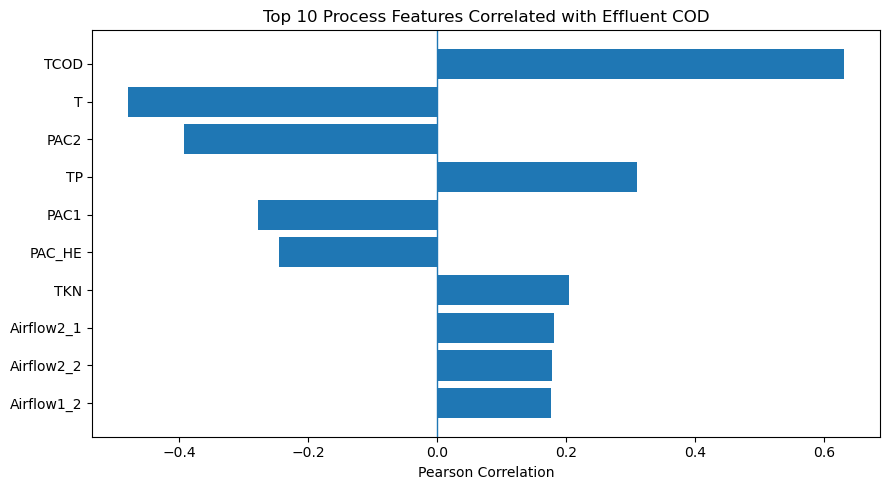

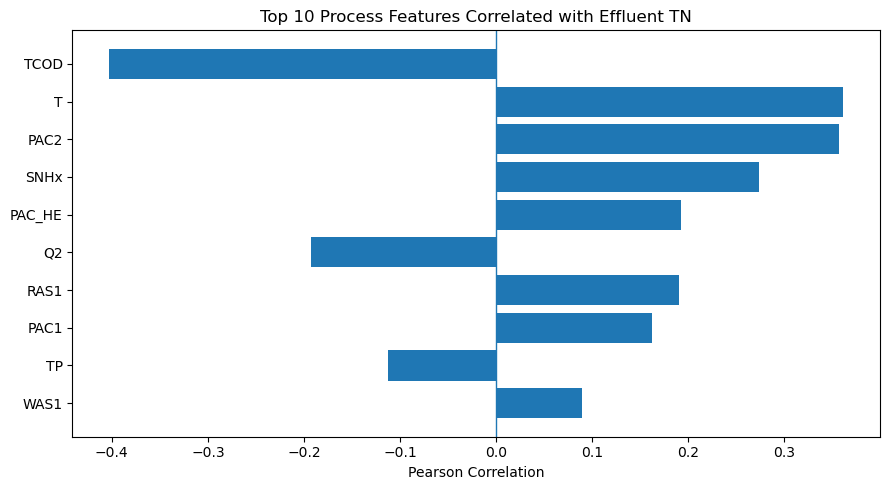

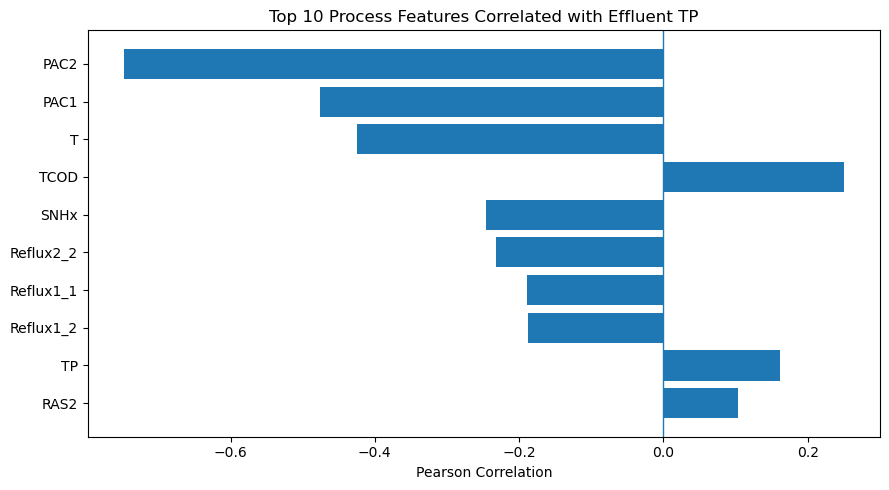

In [9]:
# ============================================================
# 8. Top 10 Features by Absolute Correlation
#
# 根据 absolute correlation 排序，
# 找出与每个 target 关系最明显的 10 个 process features。
#
# 正负号仍然保留：
# positive -> 正相关
# negative -> 负相关
# ============================================================

for name in ["COD", "TN", "TP"]:

    correlations = feature_target_corr[name]

    top10_features = (
        correlations
        .abs()
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    top10_values = correlations.loc[top10_features]

    plt.figure(figsize=(9, 5))

    plt.barh(
        top10_features[::-1],
        top10_values[::-1]
    )

    plt.axvline(0, linewidth=1)

    plt.title(
        f"Top 10 Process Features Correlated with Effluent {name}"
    )

    plt.xlabel("Pearson Correlation")

    plt.tight_layout()
    plt.show()

In [10]:
# ============================================================
# 9. Historical Eff vs Process Features
#
# 当前时间点的 eff 可以用于预测下一个时间点的 eff。
#
# 因此计算：
#
# Corr(eff_t, eff_t+1)
#
# 并与 process features 对未来 eff 的 correlation 比较。
#
# 注意：
# shift(-1) 表示下一时间点的 eff。
# ============================================================

future_corr_results = []

for name, df in datasets.items():

    temp = df.copy()

    # 下一时间点，也就是 2 小时后的 target
    temp["future_eff"] = temp["eff"].shift(-1)

    # 当前 eff 与未来 eff 的相关性
    historical_eff_corr = temp["eff"].corr(
        temp["future_eff"]
    )

    # 22 个 process features 与未来 eff 的相关性
    process_corr = (
        temp[process_features]
        .corrwith(temp["future_eff"])
    )

    strongest_feature = process_corr.abs().idxmax()
    strongest_corr = process_corr.loc[strongest_feature]

    future_corr_results.append({
        "Target": name,
        "Historical Eff -> Future Eff": historical_eff_corr,
        "Strongest Process Feature": strongest_feature,
        "Process Feature Correlation": strongest_corr
    })

future_corr_results = pd.DataFrame(future_corr_results)

future_corr_results

,Target,Historical Eff -> Future Eff,Strongest Process Feature,Process Feature Correlation
0,COD,0.997689,TCOD,0.646271
1,TN,0.996874,TCOD,-0.408420
2,TP,0.995702,PAC2,-0.750497


In [11]:
# ============================================================
# 10. Process Features 与 Future Target 的相关性
#
# Forecasting 真正关心的是：
#
# 当前 process state
#       ↓
# 2 小时后的 effluent quality
#
# 因此这里计算：
#
# feature_t vs eff_t+1
# ============================================================

future_feature_corr = {}

for name, df in datasets.items():

    temp = df.copy()

    temp["future_eff"] = temp["eff"].shift(-1)

    correlations = (
        temp[process_features]
        .corrwith(temp["future_eff"])
        .sort_values(key=abs, ascending=False)
    )

    future_feature_corr[name] = correlations

    print("\n" + "=" * 70)
    print(f"{name}: Current Features vs 2-Hour Future Effluent")
    print("=" * 70)

    print(correlations.head(10))


COD: Current Features vs 2-Hour Future Effluent
TCOD          0.646271
T            -0.478983
PAC2         -0.391278
TP            0.320868
PAC1         -0.277667
PAC_HE       -0.245601
TKN           0.215756
Airflow2_1    0.181603
Airflow2_2    0.178932
Airflow1_2    0.175935
dtype: float64

TN: Current Features vs 2-Hour Future Effluent
TCOD     -0.408420
T         0.362013
PAC2      0.356892
SNHx      0.287191
Q2       -0.200258
PAC_HE    0.190913
RAS1      0.190118
PAC1      0.162501
TP       -0.110175
TKN       0.092428
dtype: float64

TP: Current Features vs 2-Hour Future Effluent
PAC2        -0.750497
PAC1        -0.478032
T           -0.425343
TCOD         0.251535
SNHx        -0.241706
Reflux2_2   -0.231458
Reflux1_1   -0.190043
Reflux1_2   -0.188872
TP           0.171349
PAC_HE      -0.105650
dtype: float64


In [12]:
# ============================================================
# 10. Process Features 与 Future Target 的相关性
#
# Forecasting 真正关心的是：
#
# 当前 process state
#       ↓
# 2 小时后的 effluent quality
#
# 因此这里计算：
#
# feature_t vs eff_t+1
# ============================================================

future_feature_corr = {}

for name, df in datasets.items():

    temp = df.copy()

    temp["future_eff"] = temp["eff"].shift(-1)

    correlations = (
        temp[process_features]
        .corrwith(temp["future_eff"])
        .sort_values(key=abs, ascending=False)
    )

    future_feature_corr[name] = correlations

    print("\n" + "=" * 70)
    print(f"{name}: Current Features vs 2-Hour Future Effluent")
    print("=" * 70)

    print(correlations.head(10))


COD: Current Features vs 2-Hour Future Effluent
TCOD          0.646271
T            -0.478983
PAC2         -0.391278
TP            0.320868
PAC1         -0.277667
PAC_HE       -0.245601
TKN           0.215756
Airflow2_1    0.181603
Airflow2_2    0.178932
Airflow1_2    0.175935
dtype: float64

TN: Current Features vs 2-Hour Future Effluent
TCOD     -0.408420
T         0.362013
PAC2      0.356892
SNHx      0.287191
Q2       -0.200258
PAC_HE    0.190913
RAS1      0.190118
PAC1      0.162501
TP       -0.110175
TKN       0.092428
dtype: float64

TP: Current Features vs 2-Hour Future Effluent
PAC2        -0.750497
PAC1        -0.478032
T           -0.425343
TCOD         0.251535
SNHx        -0.241706
Reflux2_2   -0.231458
Reflux1_1   -0.190043
Reflux1_2   -0.188872
TP           0.171349
PAC_HE      -0.105650
dtype: float64


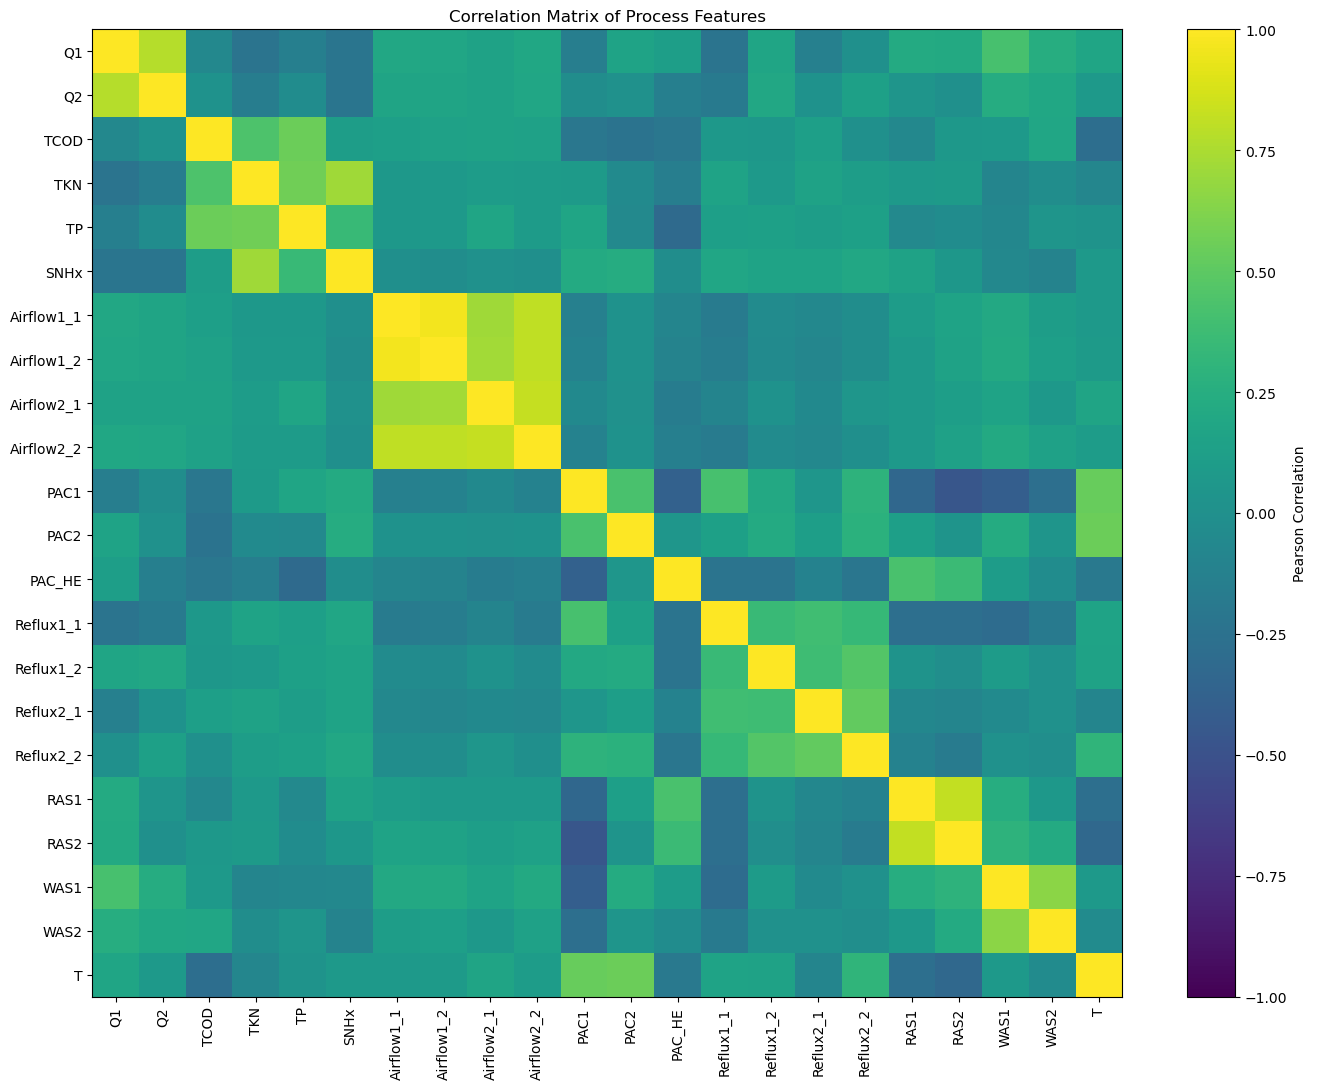

In [14]:
# ============================================================
# 11. Process Feature Correlation Matrix
#
# 分析 22 个 process features 之间是否存在较强相关性。
#
# 因为三个 CSV 的 process features 完全相同，
# 所以这里只需要使用 COD dataset。
# ============================================================

process_corr_matrix = cod[process_features].corr()

plt.figure(figsize=(14, 11))

plt.imshow(
    process_corr_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Pearson Correlation")

plt.xticks(
    range(len(process_features)),
    process_features,
    rotation=90
)

plt.yticks(
    range(len(process_features)),
    process_features
)

plt.title("Correlation Matrix of Process Features")

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 12. Highly Correlated Process Feature Pairs
#
# 找出 absolute correlation >= 0.7 的 feature pairs。
#
# 目的：
# 判断不同 process variables 是否包含较强的重复信息。
# ============================================================

high_corr_pairs = []

for i in range(len(process_features)):
    for j in range(i + 1, len(process_features)):

        feature_1 = process_features[i]
        feature_2 = process_features[j]

        corr = process_corr_matrix.loc[
            feature_1,
            feature_2
        ]

        if abs(corr) >= 0.7:

            high_corr_pairs.append({
                "Feature 1": feature_1,
                "Feature 2": feature_2,
                "Correlation": corr
            })

high_corr_pairs = pd.DataFrame(high_corr_pairs)

if len(high_corr_pairs) > 0:

    high_corr_pairs["Abs Correlation"] = (
        high_corr_pairs["Correlation"].abs()
    )

    high_corr_pairs = (
        high_corr_pairs
        .sort_values(
            "Abs Correlation",
            ascending=False
        )
        .drop(columns="Abs Correlation")
        .reset_index(drop=True)
    )

high_corr_pairs

,Feature 1,Feature 2,Correlation
0,Airflow1_1,Airflow1_2,0.964542
1,Airflow2_1,Airflow2_2,0.825146
2,RAS1,RAS2,0.817083
3,Airflow1_2,Airflow2_2,0.812051
4,Airflow1_1,Airflow2_2,0.809098
5,Q1,Q2,0.773607
6,Airflow1_2,Airflow2_1,0.725596
7,TKN,SNHx,0.715312
8,Airflow1_1,Airflow2_1,0.713175


In [16]:
# ============================================================
# 13. Top Features Summary
#
# 为 COD、TN、TP 分别找出与未来 target
# absolute correlation 最大的 5 个 process features。
# ============================================================

top_features_summary = {}

for name in ["COD", "TN", "TP"]:

    correlations = future_feature_corr[name]

    top5 = (
        correlations
        .abs()
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )

    top_features_summary[name] = top5

    print(f"\n{name}:")
    
    for feature in top5:
        print(
            f"{feature:15s} "
            f"{correlations[feature]:.4f}"
        )


COD:
TCOD            0.6463
T               -0.4790
PAC2            -0.3913
TP              0.3209
PAC1            -0.2777

TN:
TCOD            -0.4084
T               0.3620
PAC2            0.3569
SNHx            0.2872
Q2              -0.2003

TP:
PAC2            -0.7505
PAC1            -0.4780
T               -0.4253
TCOD            0.2515
SNHx            -0.2417


In [17]:
# ============================================================
# 13. Top Features Summary
#
# 为 COD、TN、TP 分别找出与未来 target
# absolute correlation 最大的 5 个 process features。
# ============================================================

top_features_summary = {}

for name in ["COD", "TN", "TP"]:

    correlations = future_feature_corr[name]

    top5 = (
        correlations
        .abs()
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )

    top_features_summary[name] = top5

    print(f"\n{name}:")
    
    for feature in top5:
        print(
            f"{feature:15s} "
            f"{correlations[feature]:.4f}"
        )


COD:
TCOD            0.6463
T               -0.4790
PAC2            -0.3913
TP              0.3209
PAC1            -0.2777

TN:
TCOD            -0.4084
T               0.3620
PAC2            0.3569
SNHx            0.2872
Q2              -0.2003

TP:
PAC2            -0.7505
PAC1            -0.4780
T               -0.4253
TCOD            0.2515
SNHx            -0.2417


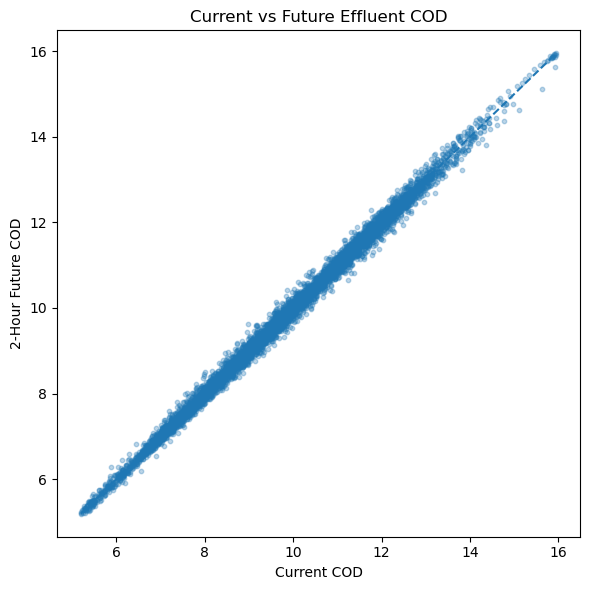

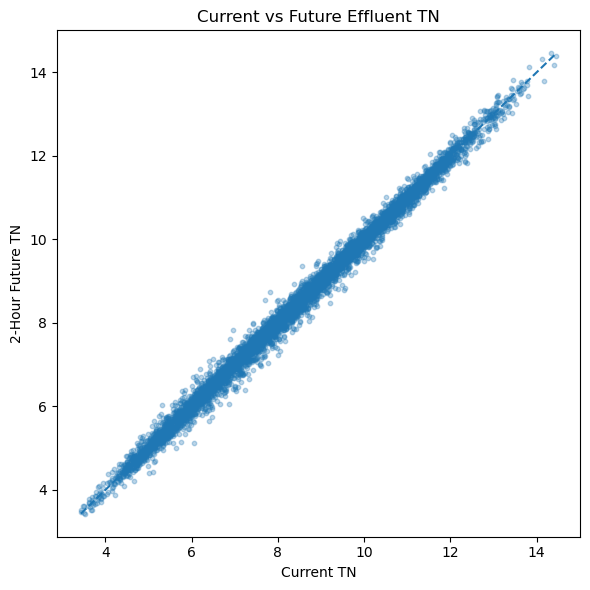

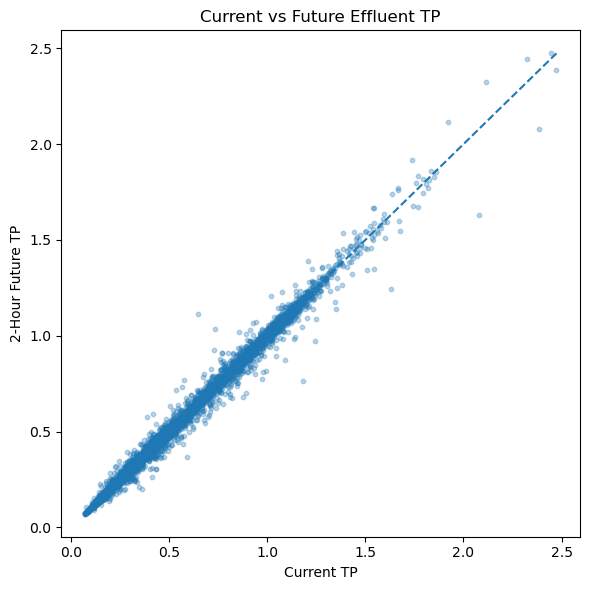

In [18]:
# ============================================================
# 15. Current Effluent vs Future Effluent
#
# 比较：
#
# 当前 eff_t
# vs
# 两小时后的 eff_t+1
#
# 如果散点高度集中在 y = x 附近，
# 说明当前值本身就是非常强的短期预测变量。
# ============================================================

for name, df in datasets.items():

    current = df["eff"].iloc[:-1]
    future = df["eff"].shift(-1).iloc[:-1]

    plt.figure(figsize=(6, 6))

    plt.scatter(
        current,
        future,
        alpha=0.3,
        s=10
    )

    min_value = min(current.min(), future.min())
    max_value = max(current.max(), future.max())

    # y = x reference line
    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.xlabel(f"Current {name}")
    plt.ylabel(f"2-Hour Future {name}")

    plt.title(
        f"Current vs Future Effluent {name}"
    )

    plt.tight_layout()
    plt.show()

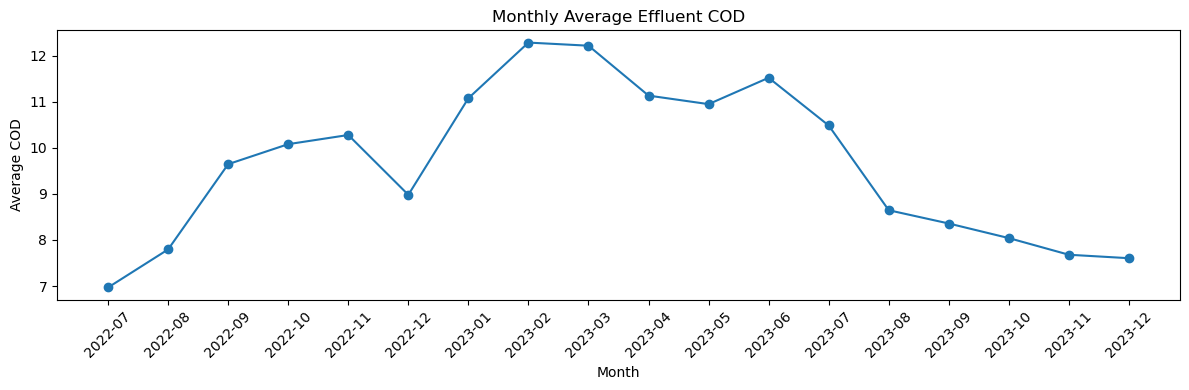

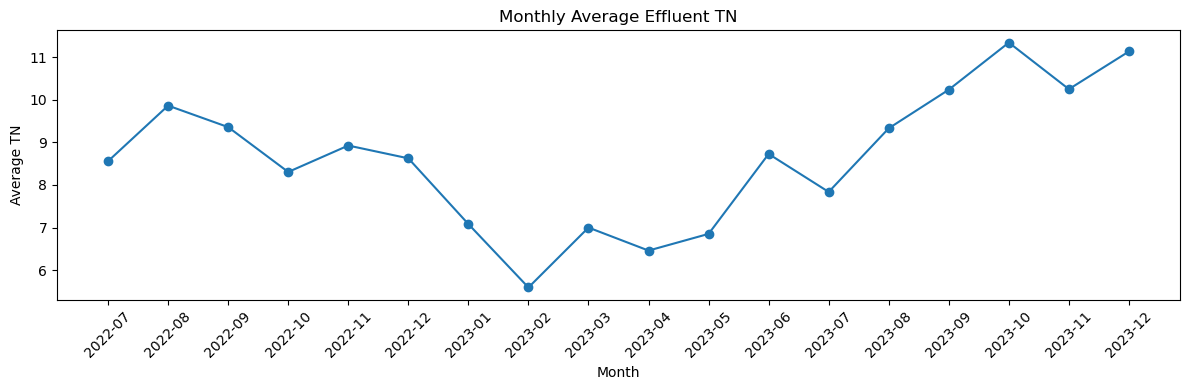

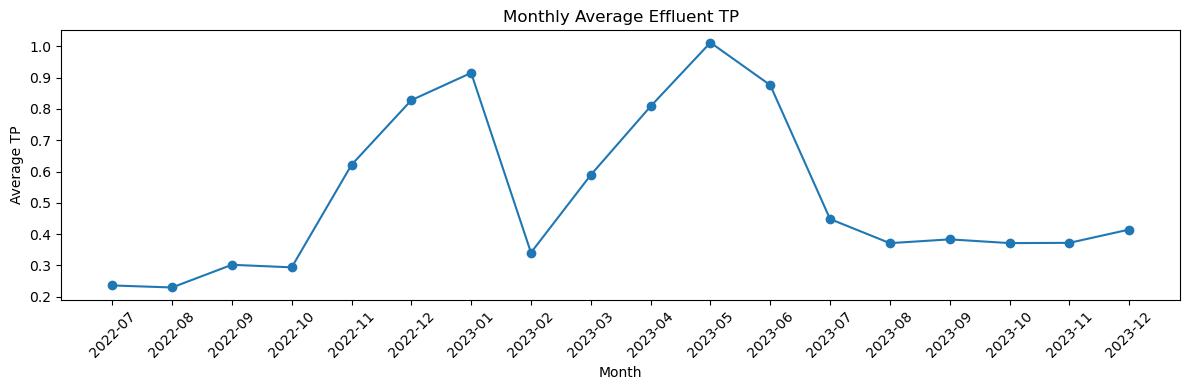

In [19]:
# ============================================================
# 16. Monthly Target Pattern
#
# 查看不同月份 COD、TN、TP 的平均出水水平。
#
# 目的：
# 初步观察 target 是否存在长期或季节性变化。
#
# 注意：
# 数据只覆盖约一年半，
# 因此这里不能据此直接证明存在稳定的季节性规律。
# ============================================================

for name, df in datasets.items():

    temp = df.copy()

    temp["month"] = temp["sampling_time"].dt.to_period("M")

    monthly_mean = (
        temp
        .groupby("month")["eff"]
        .mean()
    )

    plt.figure(figsize=(12, 4))

    plt.plot(
        monthly_mean.index.astype(str),
        monthly_mean.values,
        marker="o"
    )

    plt.title(
        f"Monthly Average Effluent {name}"
    )

    plt.xlabel("Month")
    plt.ylabel(f"Average {name}")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [20]:
# ============================================================
# 17. EDA Summary
#
# 自动整理后续建模最重要的信息：
#
# - Lag-1 autocorrelation
# - 两小时平均变化幅度
# - 95th percentile change
# - 与未来 target 最相关的 process feature
# ============================================================

eda_summary = []

for name, df in datasets.items():

    abs_change = df["eff"].diff().abs()

    temp = df.copy()
    temp["future_eff"] = temp["eff"].shift(-1)

    process_corr = (
        temp[process_features]
        .corrwith(temp["future_eff"])
    )

    strongest_feature = (
        process_corr
        .abs()
        .idxmax()
    )

    eda_summary.append({

        "Target": name,

        "Lag-1 Autocorrelation":
            df["eff"].corr(
                df["eff"].shift(1)
            ),

        "Mean 2-Hour Absolute Change":
            abs_change.mean(),

        "Median 2-Hour Absolute Change":
            abs_change.median(),

        "95% Change Threshold":
            abs_change.quantile(0.95),

        "Strongest Process Feature":
            strongest_feature,

        "Feature-Future Correlation":
            process_corr[strongest_feature]
    })

eda_summary = pd.DataFrame(eda_summary)

eda_summary

,Target,Lag-1 Autocorrelation,Mean 2-Hour Absolute Change,Median 2-Hour Absolute Change,95% Change Threshold,Strongest Process Feature,Feature-Future Correlation
0,COD,0.997689,0.102181,0.078195,0.274489,TCOD,0.646271
1,TN,0.996874,0.126275,0.096420,0.346103,TCOD,-0.408420
2,TP,0.995702,0.016921,0.009711,0.056245,PAC2,-0.750497
